# Implémentation et comparaison d'algorithmes d'apprentissage par renforcement sur cinq environnements

*Programmation dynamique, Monte Carlo, Temporal Difference Learning et Planning*

2026-4A-IABD, (Deep) Reinforcement Learning P1

Groupe : [noms à compléter]


## 1. Introduction

Ce notebook présente le travail réalisé dans le cadre du projet de Reinforcement Learning. Le but du projet est d'implémenter les principaux algorithmes classiques de l'apprentissage par renforcement (programmation dynamique, Monte Carlo, Temporal Difference Learning et Planning) et de les tester sur plusieurs environnements pour comprendre dans quels cas chaque méthode fonctionne bien, et pourquoi.

Deux bibliothèques ont été développées séparément. La première regroupe les environnements (Line World, Grid World, Two Round Rock Paper Scissors, Monty Hall et les environnements secrets fournis), qui suivent tous la même interface commune pour pouvoir être utilisés indifféremment par tous les algorithmes. La deuxième regroupe les algorithmes eux-mêmes.

Ce notebook recharge les résultats déjà calculés et sauvegardés dans `results/` (voir `scripts/run_experiments.py`, `scripts/run_hyperparameter_study.py` et `scripts/run_secret_envs_experiments.py`) plutôt que de relancer tous les entraînements en direct, pour rester rapide et reproductible.

In [1]:
import os
import sys
import csv

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
FIGURES_DIR = os.path.join(REPO_ROOT, 'report', 'figures')

def load_csv(name):
    with open(os.path.join(RESULTS_DIR, name)) as f:
        return pd.DataFrame(list(csv.DictReader(f)))


## 2. Les environnements

Chaque environnement expose la même interface : on peut le réinitialiser, jouer une action, savoir si la partie est terminée, connaître l'état courant et le score, et afficher l'état de façon lisible dans le terminal.

**Line World.** L'agent se déplace sur une ligne de plusieurs cases, part du milieu, et choisit d'aller à gauche ou à droite. Sortir par la gauche donne -1, sortir par la droite donne +1.

**Grid World.** L'agent se déplace sur une grille (5x5 par défaut) en partant du coin en haut à gauche, doit atteindre une case objectif (+1) en évitant une case piège (-1). Une action qui ferait sortir l'agent de la grille le laisse simplement sur place.

**Two Round Rock Paper Scissors.** Partie de pierre-feuille-ciseaux en deux manches. Au round 1 l'adversaire joue au hasard, au round 2 il est forcé de rejouer le coup de l'agent au round 1.

**Monty Hall (niveaux 1 et 2).** Reproduit le paradoxe de Monty Hall à 3 portes (niveau 1) ou 5 portes (niveau 2). Les deux niveaux sont gérés par la même classe, paramétrée par le nombre de portes. L'état exposé n'est pas la porte choisie (toutes les portes non choisies sont interchangeables) mais le nombre de portes restantes et la probabilité que le choix actuel soit gagnant, qui suit une formule connue du paradoxe.

**Environnements secrets (0 à 3).** Fournis par le cours sous forme de bibliothèque compilée. Adaptés à l'interface commune du projet (voir section 7). Leurs espaces d'états vont de 8192 à plus de 2 millions d'états.

In [2]:
from src.rl.environments.line_world import LineWorldEnv
from src.rl.environments.grid_world import GridWorldEnv

print('Line World :')
LineWorldEnv(num_cells=5).display()
print()
print('Grid World :')
GridWorldEnv().display()


Line World :
__X__

Grid World :
X....
.....
.....
.....
...TG


## 3. Les algorithmes

**Programmation dynamique** (modèle de l'environnement connu à l'avance) : *Value Iteration* met à jour directement la valeur de chaque état avec sa meilleure action possible. *Policy Iteration* alterne évaluation complète de la politique courante et amélioration gloutonne.

**Méthodes Monte Carlo** (apprennent en jouant des épisodes complets) : *Monte Carlo ES* démarre chaque épisode sur un état et une action tirés au hasard. *On-policy first visit MC control* garde un point de départ fixe et explore via une politique epsilon-soft. *Off-policy MC control* sépare la politique qui joue (comportement uniforme) de la politique améliorée, avec un ratio d'échantillonnage préférentiel.

**Temporal Difference Learning** (mise à jour après chaque pas, pas besoin d'attendre la fin de l'épisode) : *Sarsa* est on-policy, *Q-Learning* est off-policy (se sert directement de la meilleure action possible du pas suivant).

**Planning** : *Dyna-Q* combine l'apprentissage direct de Q-Learning avec un modèle appris de l'environnement, rejoué plusieurs fois par pas réel pour accélérer la convergence.

### Un problème commun trouvé pendant les tests

En construisant la comparaison complète (section 5), un bug a été trouvé dans Sarsa, Q-Learning, Dyna-Q et Monte Carlo ES : quand plusieurs actions ont exactement la même valeur estimée, `numpy.argmax` choisit toujours la première. Sur Grid World, avec un gamma proche de 1, une action qui ramène l'agent sur lui-même (un mur heurté) n'est presque jamais pénalisée par la mise à jour, donc si elle gagne ce départage dès le début, rien ne l'empêche de continuer à le gagner, et l'agent reste bloqué à la répéter indéfiniment. La correction retenue a été de départager les égalités au hasard plutôt que de toujours prendre la première.

## 4. Méthodologie expérimentale

Pour chaque combinaison (environnement, algorithme), l'algorithme est entraîné puis la politique obtenue est évaluée sur 200 épisodes joués sans apprentissage (action gloutonne à chaque pas). Les algorithmes de programmation dynamique sont lancés une fois (peu sensibles au hasard une fois convergés), les méthodes model-free sont relancées sur 5 graines aléatoires pour mesurer un taux de réussite plutôt qu'un seul résultat qui pourrait être une coïncidence.

Un run est réussi si son score moyen atteint le score optimal réel de l'environnement (calculé avec Value Iteration) moins une marge de 0,1 : un seuil identique partout n'aurait pas de sens, le score optimal de Monty Hall est de 2/3 (3 portes) ou 4/5 (5 portes), pas de 1.

epsilon a été porté à 0,3 (au lieu de 0,1 par défaut) pour Sarsa, Q-Learning, Dyna-Q et l'on-policy MC control, à cause du problème d'exploration décrit en section 3 et étudié en section 6.

## 5. Résultats de la comparaison

In [3]:
baseline = load_csv('baseline_comparison.csv')
baseline['mean_score'] = baseline['mean_score'].astype(float)
baseline['success_rate'] = baseline['success_rate'].astype(float)
baseline['optimal_score'] = baseline['optimal_score'].astype(float)
baseline

,environment,algorithm,optimal_score,seeds_count,mean_score,std_score,success_rate,avg_training_time_seconds
0,line_world,policy_iteration,0.999999,1,1.000,0.0,1.0,0.01795172691345215
1,line_world,value_iteration,0.999999,1,1.000,0.0,1.0,0.0002522468566894531
2,line_world,monte_carlo_es,0.999999,5,1.000,0.0,1.0,0.25421886444091796
3,line_world,on_policy_first_visit_mc,0.999999,5,1.000,0.0,1.0,0.5193305969238281
4,line_world,off_policy_mc,0.999999,5,1.000,0.0,1.0,0.3192745685577393
5,line_world,sarsa,0.999999,5,1.000,0.0,1.0,0.20409460067749025
6,line_world,q_learning,0.999999,5,1.000,0.0,1.0,0.25958986282348634
7,line_world,dyna_q,0.999999,5,1.000,0.0,1.0,0.519225788116455
8,grid_world,policy_iteration,0.999993,1,1.000,0.0,1.0,1.2960946559906006
9,grid_world,value_iteration,0.999993,1,1.000,0.0,1.0,0.057273149490356445


Tous les algorithmes atteignent 100% de réussite sur Line World, Two Round RPS et Monty Hall (quelques scores légèrement en dessous de 100% sur RPS viennent surtout du bruit d'évaluation, puisque le premier round y reste aléatoire même avec une politique optimale).

C'est sur Grid World que les différences sont les plus visibles : la programmation dynamique, Monte Carlo ES, l'off-policy MC control, Q-Learning et Dyna-Q atteignent 100%, Sarsa 80%, et l'on-policy first visit MC control échoue complètement (0%). Cet échec s'explique par sa nature même : cette méthode a besoin d'un épisode complet pour faire la moindre mise à jour, et très peu d'épisodes atteignent l'objectif ou le piège pendant l'entraînement à cause du problème d'exploration de la section 3. Sarsa et Q-Learning, eux, apprennent un peu à chaque pas grâce au bootstrap, ce qui les rend plus robustes.

Sur les deux niveaux de Monty Hall, Dyna-Q est nettement moins fiable (60%) que les autres méthodes, sans doute à cause de son modèle appris qui suppose un environnement déterministe, ce qui colle mal avec la nature probabiliste de l'état de Monty Hall.

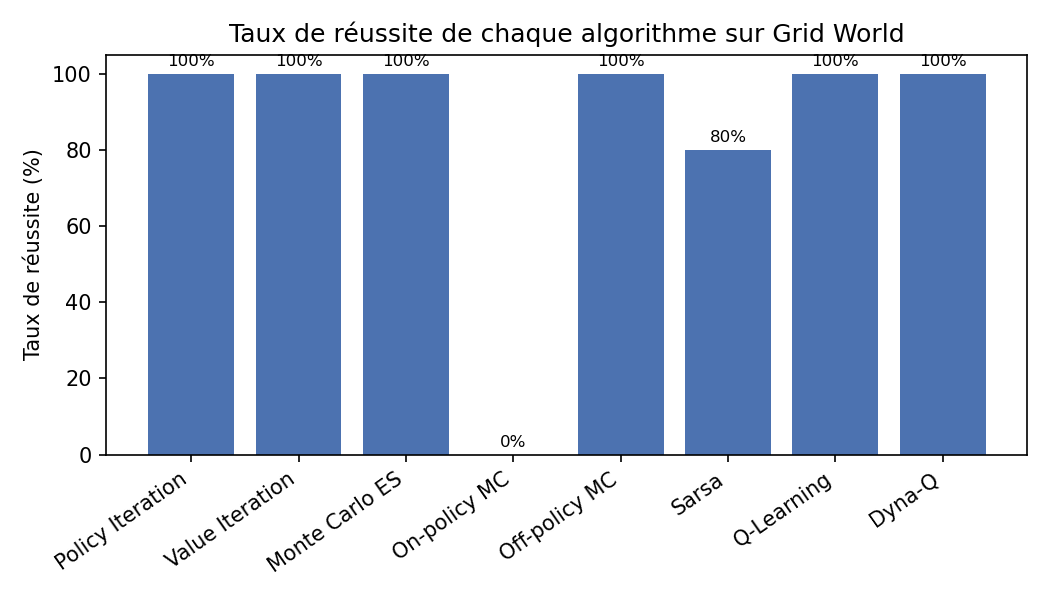

In [4]:
display(Image(os.path.join(FIGURES_DIR, 'success_rate_grid_world.png')))

## 6. Étude des hyperparamètres

In [5]:
hyperparams = load_csv('hyperparameter_study.csv')
hyperparams

,algorithm,environment,epsilon,gamma,mean_score,planning_steps,start_state_value,study,success_rate
0,sarsa,,0.1,,0.8,,,epsilon_on_grid_world,0.8
1,sarsa,,0.3,,0.8,,,epsilon_on_grid_world,0.8
2,sarsa,,0.5,,0.6,,,epsilon_on_grid_world,0.6
3,sarsa,,0.8,,0.4,,,epsilon_on_grid_world,0.4
4,on_policy_first_visit_mc,,0.1,,0.4,,,epsilon_on_grid_world,0.4
5,on_policy_first_visit_mc,,0.3,,0.0,,,epsilon_on_grid_world,0.0
6,on_policy_first_visit_mc,,0.5,,0.0,,,epsilon_on_grid_world,0.0
7,on_policy_first_visit_mc,,0.8,,0.8,,,epsilon_on_grid_world,0.8
8,,,,,0.8,0,,planning_steps_on_grid_world,0.8
9,,,,,1.0,5,,planning_steps_on_grid_world,1.0


**Epsilon sur Grid World.** Le taux de réussite de Sarsa baisse quand epsilon dépasse 0,3 (trop d'aléatoire nuit à la politique finale), alors que celui de l'on-policy MC control fait l'inverse (il lui faut beaucoup d'exploration pour qu'un épisode se termine ne serait-ce qu'une fois).

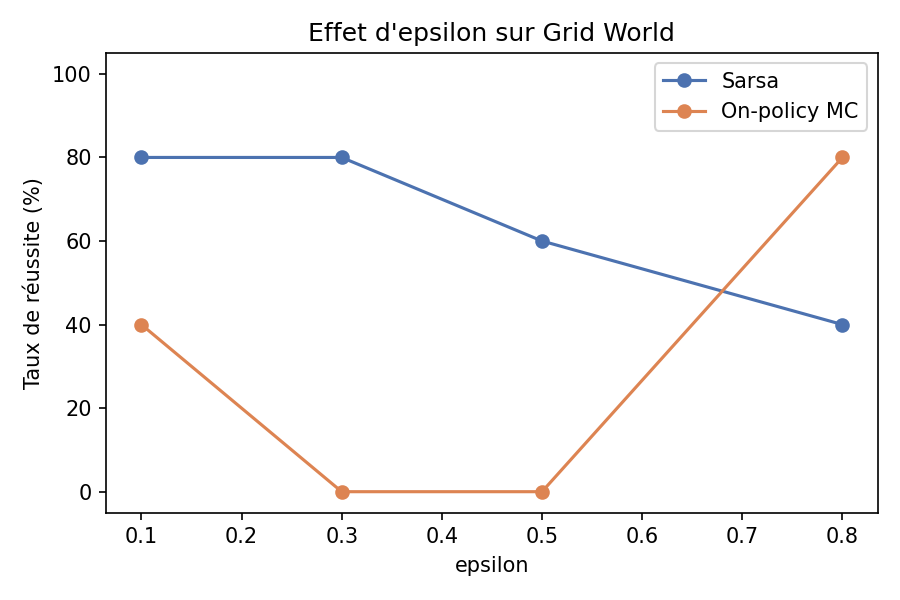

In [6]:
display(Image(os.path.join(FIGURES_DIR, 'epsilon_study.png')))

**Pas de planification sur Dyna-Q.** À seulement 500 épisodes réels, 0 pas de planification (= Q-Learning pur) donne 80% de réussite, 5 pas ou plus donnent 100%. La planification permet d'obtenir plus de mises à jour utiles de Q à partir des mêmes interactions réelles.

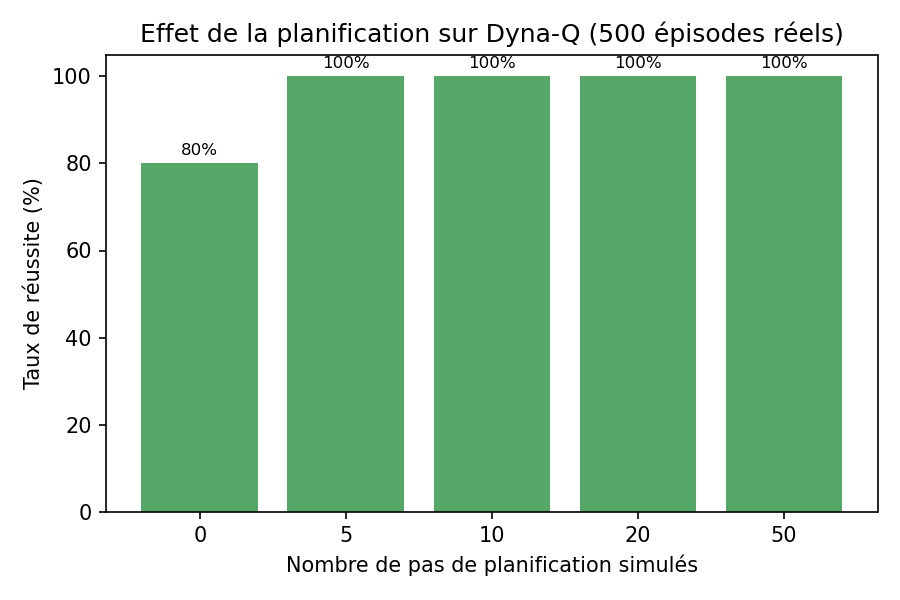

In [7]:
display(Image(os.path.join(FIGURES_DIR, 'planning_steps_study.png')))

**Gamma sur Value Iteration.** Sur Line World (chemin court), la valeur suit presque directement gamma. Sur Grid World (chemin d'environ 8 pas), l'effet est spectaculaire : gamma=0,5 donne une valeur quasi nulle (0,008), gamma=0,999999 donne une valeur proche de 1. Un gamma trop petit dévalue très fortement les récompenses qui demandent plusieurs pas pour être atteintes.

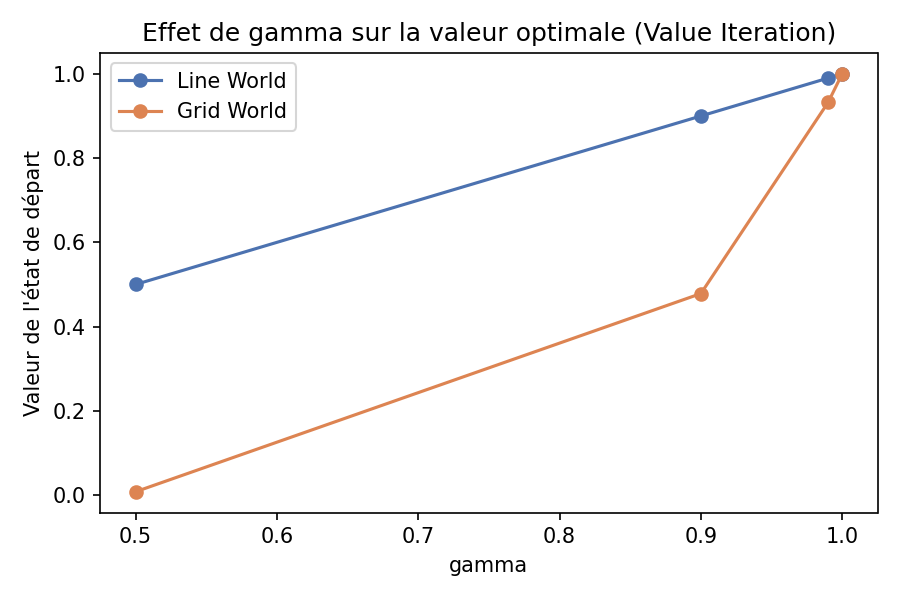

In [8]:
display(Image(os.path.join(FIGURES_DIR, 'gamma_study.png')))

## 7. Intégration et résultats sur les environnements secrets

Les environnements secrets (0 à 3) sont fournis par le cours sous forme de bibliothèque compilée et d'un wrapper Python (`secret_envs/`), déjà disponibles avant même la fin du cours : seule l'interface graphique manque encore. `SecretEnvAdapter` (`src/rl/environments/secret_envs.py`) les adapte à l'interface commune du projet, ce qui les rend utilisables par tous les algorithmes model-free (Sarsa, Q-Learning, Dyna-Q, Monte Carlo on-policy/off-policy) sans écrire de code spécifique.

Deux limites assumées : ces environnements n'exposent pas de moyen de se replacer directement dans un état donné, donc Monte Carlo ES ne s'y applique pas. Leurs espaces d'états (de 8192 à plus de 2 millions d'états) rendent aussi la programmation dynamique impraticable avec l'implémentation du projet, qui énumère explicitement toutes les combinaisons (état, action, état suivant, récompense) à chaque passage.

In [9]:
secret_envs_results = load_csv('secret_envs/secret_envs_comparison.csv')
secret_envs_results['mean_score'] = secret_envs_results['mean_score'].astype(float)
secret_envs_results

,environment,algorithm,mean_score,mean_episode_length,source_file
0,secret_env_0,dyna_q,10.0,63.0,secret_env_0__dyna_q__epsilon=0.3_iterations_c...
1,secret_env_0,off_policy_monte_carlo_control,-3.0,63.0,secret_env_0__off_policy_monte_carlo_control__...
2,secret_env_0,on_policy_first_visit_monte_carlo_control,10.0,63.0,secret_env_0__on_policy_first_visit_monte_carl...
3,secret_env_0,q_learning,9.0,63.0,secret_env_0__q_learning__epsilon=0.3_iteratio...
4,secret_env_0,sarsa,9.0,63.0,secret_env_0__sarsa__epsilon=0.3_iterations_co...
5,secret_env_1,dyna_q,31.0,255.0,secret_env_1__dyna_q__epsilon=0.3_iterations_c...
6,secret_env_1,off_policy_monte_carlo_control,-13.0,255.0,secret_env_1__off_policy_monte_carlo_control__...
7,secret_env_1,on_policy_first_visit_monte_carlo_control,27.0,255.0,secret_env_1__on_policy_first_visit_monte_carl...
8,secret_env_1,q_learning,23.0,255.0,secret_env_1__q_learning__epsilon=0.3_iteratio...
9,secret_env_1,sarsa,30.0,255.0,secret_env_1__sarsa__epsilon=0.3_iterations_co...


Secret Env 3 n'apparaît pas dans ce tableau : la bibliothèque compilée fournie plante systématiquement (message "Forbidden action") sur cet environnement, quel que soit l'algorithme testé (les 5 ont été essayés) et quelle que soit la graine aléatoire utilisée (3 tentatives par algorithme). Ce comportement n'a pas pu être reproduit de façon isolée pour en identifier la cause exacte : c'est une limite de la bibliothèque fournie, pas un problème dans le code du projet, qui gère cet échec proprement (chaque combinaison tourne dans un processus séparé, pour qu'un plantage n'empêche pas de tester les autres).

Sur les 3 environnements secrets exploitables, Dyna-Q obtient le meilleur score sur Secret Env 0 et Secret Env 1, ce qui confirme l'avantage de la planification déjà observé sur Grid World (section 6.2). Sur Secret Env 2 (plus de 2 millions d'états), tous les algorithmes obtiennent un score négatif : avec seulement 1500 à 3000 itérations (budget réduit pour rester dans un temps raisonnable), la couverture de cet espace d'états est trop faible pour apprendre une bonne stratégie. C'est une limite honnête du travail réalisé, pas un échec caché : il faudrait beaucoup plus d'itérations, ou une méthode capable de généraliser entre états proches plutôt que d'apprendre chaque état indépendamment (ce que ne font pas les méthodes tabulaires utilisées ici), pour espérer un meilleur résultat sur un espace d'états aussi grand.

## 8. Quel algorithme choisir, et pourquoi

Sur les environnements les plus simples (Line World, Two Round RPS, Monty Hall), tous les algorithmes se valent à peu près. Les différences intéressantes apparaissent sur Grid World, qui a un espace d'états plus grand et une récompense qui n'arrive qu'après plusieurs pas coordonnés.

Quand le modèle de l'environnement est connu à l'avance, la programmation dynamique reste le choix le plus sûr et le plus rapide. Quand le modèle n'est pas connu, Q-Learning est la méthode la plus robuste dans l'ensemble. Dyna-Q apprend plus vite que Q-Learning à nombre d'épisodes réels égal sur Grid World grâce à sa planification, mais c'est aussi l'algorithme le moins fiable sur Monty Hall. Sarsa reste correct mais un peu moins fiable que Q-Learning sur Grid World. L'on-policy first visit MC control est clairement le moins adapté à Grid World dans sa configuration par défaut, à cause de son besoin d'épisodes complets. Monte Carlo ES et l'off-policy MC control restent fiables sur tous les environnements testés, mais Monte Carlo ES a besoin que l'environnement sache se replacer directement dans un état donné, ce qui n'est pas toujours possible.

## 9. Limites et perspectives

L'algorithme optionnel Dyna-Q+ n'a pas été implémenté, faute de temps disponible avant la date de rendu. L'interface graphique des environnements secrets n'était pas encore fournie au moment de la rédaction, seule leur interface en ligne de commande a été utilisée. Secret Env 3 n'a pas pu être testé du tout (bibliothèque fournie qui plante systématiquement), et Secret Env 2 n'a pas de stratégie satisfaisante à cause de son espace d'états bien trop grand (plus de 2 millions d'états) pour le budget d'itérations utilisé. Dyna-Q reste moins fiable que les autres méthodes sur Monty Hall, une piste à creuser serait d'adapter son modèle appris pour mieux gérer les environnements dont l'état encode une information probabiliste plutôt qu'une position concrète.

## 10. Conclusion

Ce projet a permis d'implémenter huit algorithmes classiques de l'apprentissage par renforcement et plusieurs environnements partageant une interface commune, puis de les comparer de façon systématique. Les résultats confirment que la plupart des algorithmes fonctionnent bien sur des environnements simples, mais que des différences importantes apparaissent dès que l'environnement devient plus grand ou que la récompense demande plusieurs actions coordonnées. Le travail a aussi permis de découvrir et corriger un vrai problème d'exploration lié au départage des égalités dans le calcul de la meilleure action, ce qui montre l'intérêt de tester les algorithmes sur des environnements variés plutôt que sur un seul cas simple.